In [1]:
import tensorflow as tf
import tensorflow_model_optimization as tfmot
import numpy as np
import time
import os
import matplotlib.pyplot as plt
from math import pi

In [2]:
# =========================================================
# 1. ETL DEL DATASET (MNIST Reducido para agilidad)
# =========================================================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = (x_train.astype('float32') / 255.0)[..., np.newaxis][:10000]
y_train = y_train[:10000]
x_test = (x_test.astype('float32') / 255.0)[..., np.newaxis][:1000]
y_test = y_test[:1000]

def representative_dataset():
    for data in tf.data.Dataset.from_tensor_slices(x_train).batch(1).take(100):
        yield [data]

In [3]:
# =========================================================
# 2. DEFINICIÓN DE ARQUITECTURAS (Completa vs Podada Estructurada)
# =========================================================
# Arquitectura Original (100% MACs)
def build_full_model():
    return tf.keras.Sequential([
        tf.keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

# Arquitectura Podada Estructurada (~50% menos canales/filtros -> Reducción real de MACs)
def build_pruned_model():
    return tf.keras.Sequential([
        tf.keras.layers.Conv2D(8, (3, 3), activation='relu', input_shape=(28, 28, 1)), # De 16 a 8
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(32, activation='relu'), # De 64 a 32
        tf.keras.layers.Dense(10, activation='softmax')
    ])

print("Entrenando Modelos Base en FP32...")
model_full = build_full_model()
model_full.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_full.fit(x_train, y_train, epochs=2, batch_size=64, validation_split=0.1, verbose=0)
model_full.save('model_base_full.keras')

model_pruned = build_pruned_model()
model_pruned.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_pruned.fit(x_train, y_train, epochs=2, batch_size=64, validation_split=0.1, verbose=0)

Entrenando Modelos Base en FP32...







In [4]:
# =========================================================
# 3. FUNCIONES DE CONVERSIÓN (PTQ y QAT)
# =========================================================
def apply_ptq(keras_model, filename):
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    tflite_model = converter.convert()
    with open(filename, 'wb') as f:
        f.write(tflite_model)

def apply_qat(keras_model, filename):
    quantize_model = tfmot.quantization.keras.quantize_model
    qat_model = quantize_model(keras_model)
    qat_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    # Fine-tuning para que recupere la precisión
    qat_model.fit(x_train, y_train, epochs=1, batch_size=64, validation_split=0.1, verbose=0)
    
    converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    with open(filename, 'wb') as f:
        f.write(converter.convert())

# Aplicar a modelo COMPLETO
print("Aplicando PTQ y QAT al modelo completo...")
apply_ptq(model_full, 'full_ptq.tflite')
apply_qat(model_full, 'full_qat.tflite')

# Aplicar a modelo PODADO (Structured Pruned)
print("Aplicando PTQ y QAT al modelo podado estructuradamente...")
apply_ptq(model_pruned, 'pruned_ptq.tflite')
apply_qat(model_pruned, 'pruned_qat.tflite')

Aplicando PTQ y QAT al modelo completo...
INFO:tensorflow:Assets written to: C:\Users\Alonso\AppData\Local\Temp\tmp6t1r0_96\assets


INFO:tensorflow:Assets written to: C:\Users\Alonso\AppData\Local\Temp\tmp6t1r0_96\assets
C:\Users\Alonso\.conda\envs\TESIS\lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INFO:tensorflow:Assets written to: C:\Users\Alonso\AppData\Local\Temp\tmpd38kkjup\assets


INFO:tensorflow:Assets written to: C:\Users\Alonso\AppData\Local\Temp\tmpd38kkjup\assets
C:\Users\Alonso\.conda\envs\TESIS\lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Aplicando PTQ y QAT al modelo podado estructuradamente...
INFO:tensorflow:Assets written to: C:\Users\Alonso\AppData\Local\Temp\tmp_03s2fi_\assets


INFO:tensorflow:Assets written to: C:\Users\Alonso\AppData\Local\Temp\tmp_03s2fi_\assets
C:\Users\Alonso\.conda\envs\TESIS\lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INFO:tensorflow:Assets written to: C:\Users\Alonso\AppData\Local\Temp\tmp0nfhpnwm\assets


INFO:tensorflow:Assets written to: C:\Users\Alonso\AppData\Local\Temp\tmp0nfhpnwm\assets
C:\Users\Alonso\.conda\envs\TESIS\lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [6]:
# =========================================================
# 4. EVALUACIÓN Y MÉTRICAS INGENIERILES
# =========================================================
def eval_tflite(model_path):
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    in_idx = interpreter.get_input_details()[0]['index']
    out_idx = interpreter.get_output_details()[0]['index']
    scale, zp = interpreter.get_input_details()[0]['quantization']
    
    correct = 0
    start = time.time()
    for i in range(len(x_test)):
        inp = x_test[i:i+1]
        if scale != 0: inp = (inp / scale + zp).astype(np.int8)
        interpreter.set_tensor(in_idx, inp)
        interpreter.invoke()
        if np.argmax(interpreter.get_tensor(out_idx)) == y_test[i]:
            correct += 1
    lat = ((time.time() - start) / len(x_test)) * 1000
    size_kb = os.path.getsize(model_path) / 1024
    return size_kb, (correct / len(x_test))*100, lat

print("\n--- RESULTADOS FINALES ---")

s_base = os.path.getsize('model_base_full.keras') / 1024
start_base = time.time()
_, acc_base = model_full.evaluate(x_test, y_test, verbose=0)
lat_base = ((time.time() - start_base) / len(x_test)) * 1000
print(f"1. Base FP32         -> Tamaño: {s_base:6.1f} KB | Acc: {acc_base*100:5.1f}% | Latencia: {lat_base:4.2f} ms")

s, a, l = eval_tflite('full_ptq.tflite')
print(f"2. Full PTQ INT8     -> Tamaño: {s:6.1f} KB | Acc: {a:5.1f}% | Latencia: {l:4.2f} ms")

s, a, l = eval_tflite('full_qat.tflite')
print(f"3. Full QAT INT8     -> Tamaño: {s:6.1f} KB | Acc: {a:5.1f}% | Latencia: {l:4.2f} ms")

s, a, l = eval_tflite('pruned_ptq.tflite')
print(f"4. Pruned PTQ INT8   -> Tamaño: {s:6.1f} KB | Acc: {a:5.1f}% | Latencia: {l:4.2f} ms")

s, a, l = eval_tflite('pruned_qat.tflite')
print(f"5. Pruned QAT INT8   -> Tamaño: {s:6.1f} KB | Acc: {a:5.1f}% | Latencia: {l:4.2f} ms")


--- RESULTADOS FINALES ---
1. Base FP32         -> Tamaño: 2066.2 KB | Acc:  92.6% | Latencia: 0.16 ms


C:\Users\Alonso\.conda\envs\TESIS\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


2. Full PTQ INT8     -> Tamaño:  175.3 KB | Acc:  92.7% | Latencia: 0.10 ms
3. Full QAT INT8     -> Tamaño:  174.0 KB | Acc:  94.4% | Latencia: 0.09 ms
4. Pruned PTQ INT8   -> Tamaño:   47.2 KB | Acc:  91.1% | Latencia: 0.06 ms
5. Pruned QAT INT8   -> Tamaño:   46.6 KB | Acc:  93.1% | Latencia: 0.06 ms


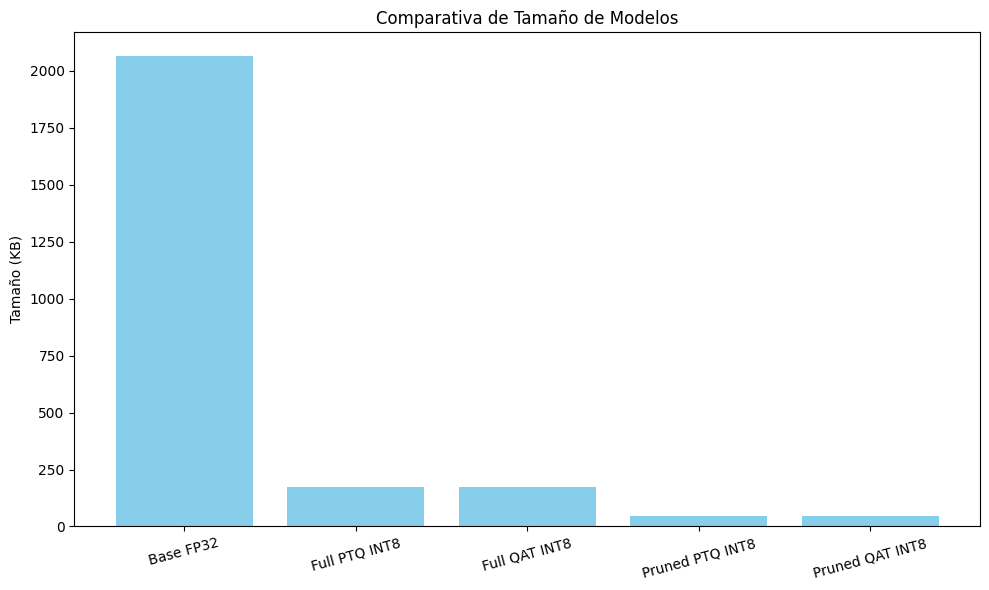

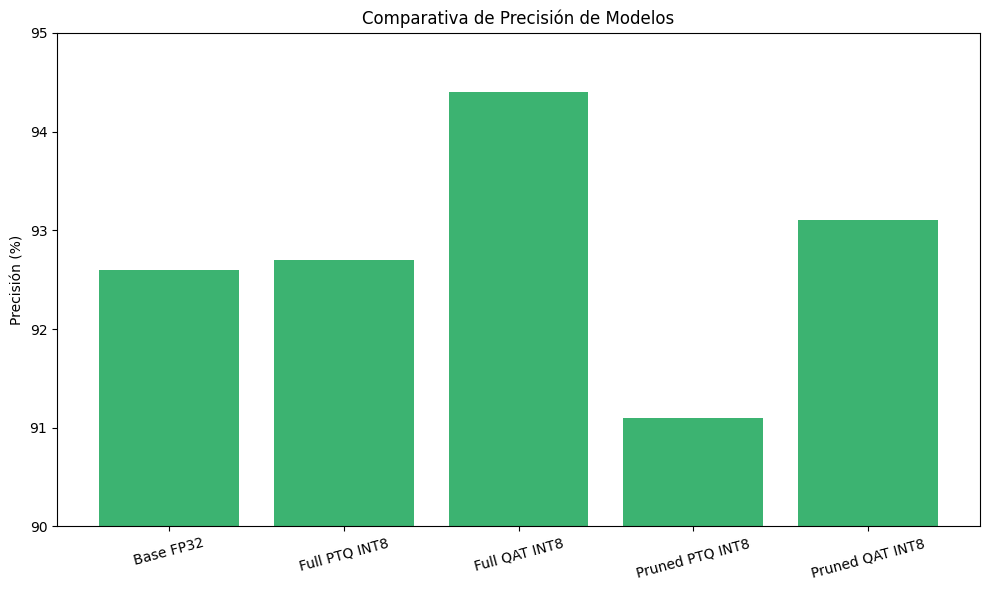

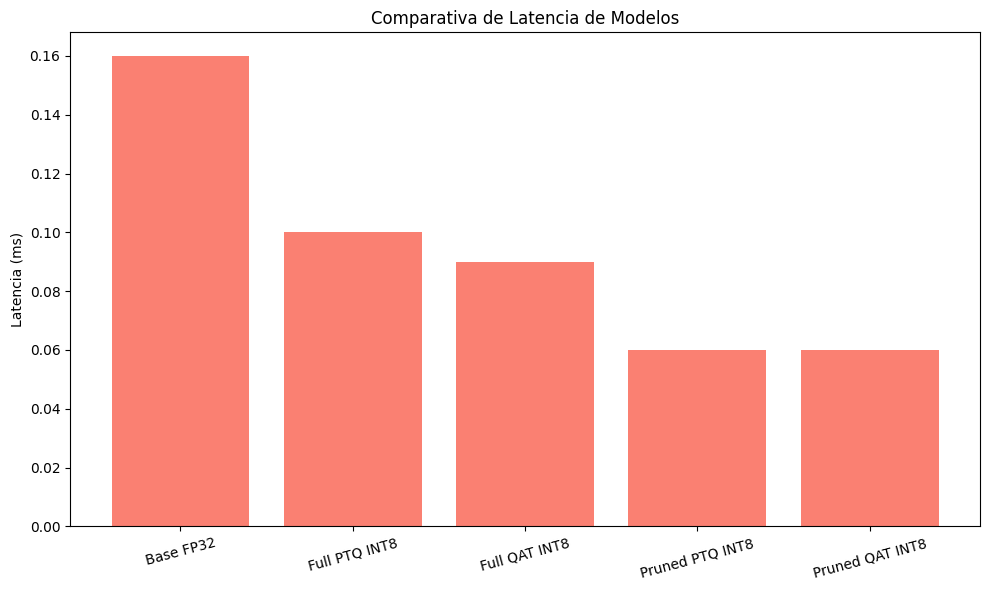

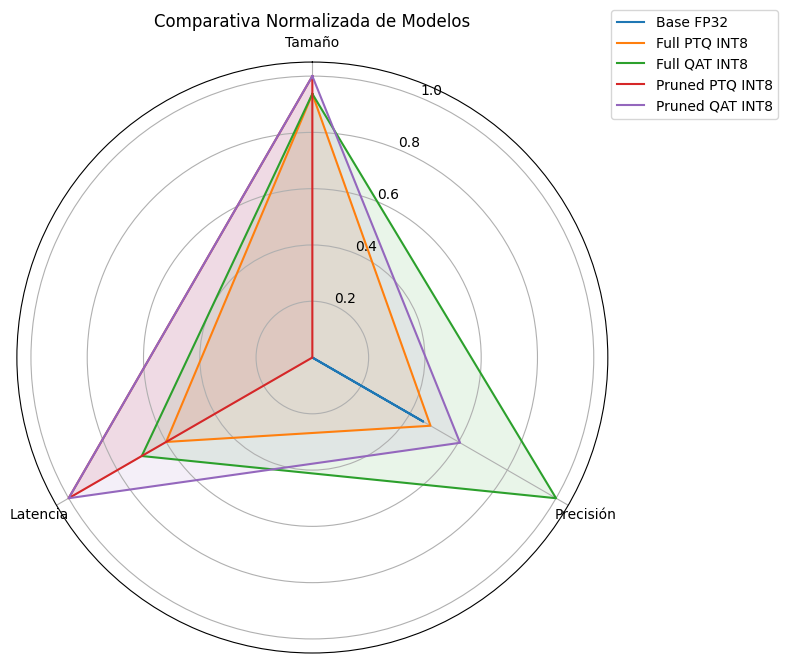

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
from math import pi

# Datos
modelos = ['Base FP32', 'Full PTQ INT8', 'Full QAT INT8', 'Pruned PTQ INT8', 'Pruned QAT INT8']
tamano = [2066.2, 175.3, 174.0, 47.2, 46.6]
precision = [92.6, 92.7, 94.4, 91.1, 93.1]
latencia = [0.16, 0.10, 0.09, 0.06, 0.06]

# 1. Gráfico de barras - Tamaño
plt.figure(figsize=(10,6))
plt.bar(modelos, tamano, color='skyblue')
plt.ylabel('Tamaño (KB)')
plt.title('Comparativa de Tamaño de Modelos')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 2. Gráfico de barras - Precisión
plt.figure(figsize=(10,6))
plt.bar(modelos, precision, color='mediumseagreen')
plt.ylabel('Precisión (%)')
plt.title('Comparativa de Precisión de Modelos')
plt.xticks(rotation=15)
plt.ylim(90, 95)
plt.tight_layout()
plt.show()

# 3. Gráfico de barras - Latencia
plt.figure(figsize=(10,6))
plt.bar(modelos, latencia, color='salmon')
plt.ylabel('Latencia (ms)')
plt.title('Comparativa de Latencia de Modelos')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 4. Gráfico Radar - Métricas normalizadas
# Normalización (menor tamaño y latencia = mejor)
tamano_norm = [1 - (x - min(tamano)) / (max(tamano) - min(tamano)) for x in tamano]
precision_norm = [(x - min(precision)) / (max(precision) - min(precision)) for x in precision]
latencia_norm = [1 - (x - min(latencia)) / (max(latencia) - min(latencia)) for x in latencia]

labels = ['Tamaño', 'Precisión', 'Latencia']
num_vars = len(labels)
angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
for i in range(len(modelos)):
    values = [tamano_norm[i], precision_norm[i], latencia_norm[i]]
    values += values[:1]
    ax.plot(angles, values, label=modelos[i])
    ax.fill(angles, values, alpha=0.1)

ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_title('Comparativa Normalizada de Modelos')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()
